In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error

In [4]:
# Step 2: Load Dataset
data = pd.read_csv("vertical_farming_dataset_300.csv")

In [5]:
# Step 3: Split Features & Target
X = data.drop("Yield", axis=1)
y = data["Yield"]


In [6]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
# Step 5: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# Step 6: Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR()
}

In [10]:
# Step 7: Train & Evaluate Models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append([name, r2, rmse])

In [11]:
# Step 8: Display Results
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print("\nModel Performance:\n")
print(results_df.sort_values(by="R2 Score", ascending=False))



Model Performance:

               Model  R2 Score       RMSE
0  Linear Regression  0.976231  16.473009
2      Random Forest  0.967575  19.240222
3  Gradient Boosting  0.964778  20.052891
1      Decision Tree  0.932910  27.675663
4                KNN  0.804474  47.246601
5                SVR  0.159904  97.933866


In [12]:
# Step 9: Best Model Selection
best_model = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]
print("\nBest Model:", best_model["Model"])


Best Model: Linear Regression


In [13]:
# Step 10: Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(feature_df)


Feature Importance:

           Feature  Importance
3  Light_Intensity    0.968564
1         Humidity    0.006439
5      Water_Usage    0.006429
4   Nutrient_Level    0.005693
2              CO2    0.004885
0      Temperature    0.004426
6      Growth_Days    0.003565


In [14]:
# Step 11: Sample Prediction
sample = [[25, 70, 600, 700, 7, 5, 30]]  # Input values
sample_scaled = scaler.transform(sample)

prediction = rf.predict(sample_scaled)
print("\nPredicted Yield:", prediction[0])


Predicted Yield: 367.74611629625923


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


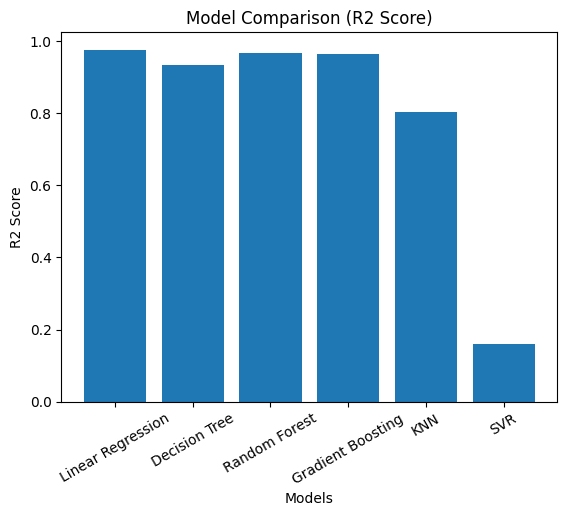

In [16]:
# 📊 Bar Chart (Model Accuracy)
import matplotlib.pyplot as plt

# Extract model names and R2 scores from results_df
names = results_df["Model"]
scores = results_df["R2 Score"]

plt.figure()
plt.bar(names, scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

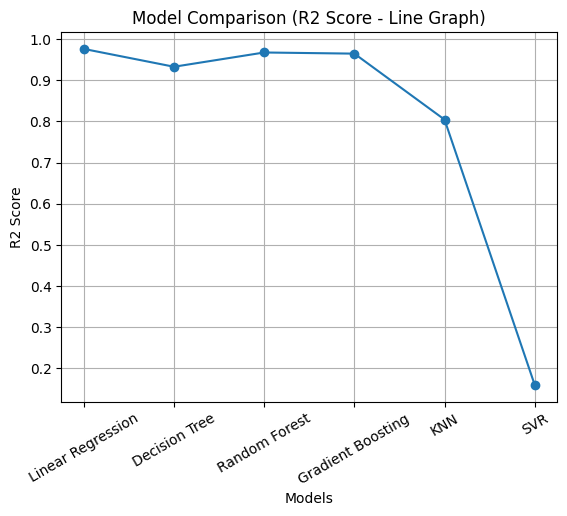

In [17]:
import matplotlib.pyplot as plt
# 📈 Line Graph
plt.figure()
plt.plot(names, scores, marker='o')
plt.title("Model Comparison (R2 Score - Line Graph)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.grid()
plt.show()